In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import itertools
import statsmodels.api as sm

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length
from pyspark.sql.functions import explode, avg
from pyspark.sql import functions as F
import pyspark.sql.functions as sf
import matplotlib.pyplot as plt
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import RandomForestClassifier

from pyspark.mllib.feature import Normalizer
from pyspark.ml.feature import VectorAssembler
import re
from pyspark.ml.stat import Correlation
from tabulate import tabulate


from IPython.core.display import HTML
display(HTML("<style>pre { white-space: pre !important; }</style>"))

In [2]:
spark = SparkSession.builder.getOrCreate()
sc = spark.sparkContext

/opt/conda/lib/python3.7/site-packages/pyspark/bin/load-spark-env.sh: line 68: ps: command not found
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


25/10/19 00:08:15 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Set the option to display all columns
pd.set_option('display.max_columns', None)

In [4]:
#path = "/Users/acgid/Downloads/nba_stats/"
#Individual Statistics
file_1 = "Player Award Shares.csv" #Truth data and dependent variable
file_2 = "Player Totals.csv"
file_3 = "Player Per Game.csv"
file_4 = "Player Play By Play.csv"
file_5 = "Player Shooting.csv"
#Advanced Individual Statistics
file_6 = "Advanced.csv"
file_7 = "Per 36 Minutes.csv"
file_8 = "Per 100 Poss.csv"

In [5]:
award_df = spark.read.csv(file_1, header=True, inferSchema=True)
plyr_tot_df = spark.read.csv(file_2, header=True, inferSchema=True)
ppg_df = spark.read.csv(file_3, header=True, inferSchema=True)
plyr_pbp_df = spark.read.csv(file_4, header=True, inferSchema=True)
plyr_shtg_df = spark.read.csv(file_5, header=True, inferSchema=True)
adv_df = spark.read.csv(file_6, header=True, inferSchema=True)
plyr_p36min_df = spark.read.csv(file_7, header=True, inferSchema=True)
plyr_p100ps_df = spark.read.csv(file_8, header=True, inferSchema=True)

In [6]:
# filter for 1980 or higher
award_df_filtered = award_df.filter(award_df.season >= 1980)
print("This is award_df_filtered after filter:",award_df_filtered.count())

plyr_tot_df_filtered = plyr_tot_df.filter(plyr_tot_df.season >= 1980)
print("This is plyr_tot_df_filtered after filter:", plyr_tot_df_filtered.count())

ppg_df_filtered = ppg_df.filter(ppg_df.season >= 1980)
print("This is ppg_df_filtered after filter:", ppg_df_filtered.count())

plyr_pbp_df_filtered = plyr_pbp_df.filter(plyr_pbp_df.season >= 1980)
print("This is plyr_pbp_df_filtered after filter:", plyr_pbp_df_filtered.count())

plyr_shtg_df_filtered = plyr_shtg_df.filter(plyr_shtg_df.season >= 1980)
print("This is plyr_shtg_df_filtered after filter:", plyr_shtg_df_filtered.count())

adv_df_filtered = adv_df.filter(adv_df.season >= 1980)
print("This is adv_df_filtered after filter:", adv_df_filtered.count())

plyr_p36min_df_filtered = plyr_p36min_df.filter(plyr_p36min_df.season >= 1980)
print("This is plyr_p36min_df_filtered after filter:", plyr_p36min_df_filtered.count())

plyr_p100ps_df_filtered = plyr_p100ps_df.filter(plyr_p100ps_df.season >= 1980)
print("This is plyr_p100ps_df_filtered after filter:", plyr_p100ps_df_filtered.count())

This is award_df_filtered after filter: 2897
This is plyr_tot_df_filtered after filter: 24616
This is ppg_df_filtered after filter: 24616
This is plyr_pbp_df_filtered after filter: 17521
This is plyr_shtg_df_filtered after filter: 17521
This is adv_df_filtered after filter: 24616
This is plyr_p36min_df_filtered after filter: 24616
This is plyr_p100ps_df_filtered after filter: 24616


In [7]:
temp1 = plyr_tot_df_filtered.join(ppg_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos", "g", "gs"], 
                                  how="left")
print("this is after merge:",temp1.count())

this is after merge: 24616


In [8]:
temp1.show()

25/10/19 00:08:34 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------+---+--------------------+---------+---+----+---+---+---+----+---+----+----------+---+----+-----------+---+----+-----------+------------+---+---+----------+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+----------+------------+-------------+-----------+------------+-------------+-----------+------------+-----------+------------+----------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+
|season| lg|              player|player_id|age|team|pos|  g| gs|  mp| fg| fga|fg_percent|x3p|x3pa|x3p_percent|x2p|x2pa|x2p_percent|e_fg_percent| ft|fta|ft_percent|orb|drb|trb|ast|stl|blk|tov| pf| pts|trp_dbl|mp_per_game|fg_per_game|fga_per_game|fg_percent|x3p_per_game|x3pa_per_game|x3p_percent|x2p_per_game|x2pa_per_game|x2p_percent|e_fg_percent|ft_per_game|fta_per_game|ft_percent|orb_per_game|drb_per_game|trb_per_game|ast_per_game|stl_per_game|blk_per_game|tov_per_game|pf_per_game|pts_per_game|


In [9]:
temp1.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'string'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'string'),
 ('mp', 'string'),
 ('fg', 'int'),
 ('fga', 'int'),
 ('fg_percent', 'string'),
 ('x3p', 'string'),
 ('x3pa', 'string'),
 ('x3p_percent', 'string'),
 ('x2p', 'string'),
 ('x2pa', 'string'),
 ('x2p_percent', 'string'),
 ('e_fg_percent', 'string'),
 ('ft', 'int'),
 ('fta', 'int'),
 ('ft_percent', 'string'),
 ('orb', 'string'),
 ('drb', 'string'),
 ('trb', 'string'),
 ('ast', 'int'),
 ('stl', 'string'),
 ('blk', 'string'),
 ('tov', 'string'),
 ('pf', 'string'),
 ('pts', 'int'),
 ('trp_dbl', 'string'),
 ('mp_per_game', 'string'),
 ('fg_per_game', 'double'),
 ('fga_per_game', 'double'),
 ('fg_percent', 'string'),
 ('x3p_per_game', 'string'),
 ('x3pa_per_game', 'string'),
 ('x3p_percent', 'string'),
 ('x2p_per_game', 'string'),
 ('x2pa_per_game', 'string'),
 ('x2p_percent', 'string'),
 ('e_fg_percent', 'string'),

In [10]:
temp2 = plyr_pbp_df_filtered.join(plyr_shtg_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp"], 
                                  how="left")

print("this is after merge:",temp2.count())



this is after merge: 17521


In [11]:
temp2.show()

+------+---+--------------------+---------+---+----+---+---+---+----+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------------+--------------------------+---------------------------+----------------------------+----------------------------+-------------------------+-----------------------+-----------------------+--------------------+------------+------------------------+----------------------+--------------------+---------------+
|season| lg|              player|player_id|age|team|pos|  g| gs|  mp|pg_percent|sg_percent|sf_percent|pf_percent|c_p

In [12]:
temp2.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'int'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'int'),
 ('mp', 'int'),
 ('pg_percent', 'string'),
 ('sg_percent', 'string'),
 ('sf_percent', 'string'),
 ('pf_percent', 'string'),
 ('c_percent', 'string'),
 ('on_court_plus_minus_per_100_poss', 'string'),
 ('net_plus_minus_per_100_poss', 'string'),
 ('bad_pass_turnover', 'int'),
 ('lost_ball_turnover', 'int'),
 ('shooting_foul_committed', 'int'),
 ('offensive_foul_committed', 'int'),
 ('shooting_foul_drawn', 'int'),
 ('offensive_foul_drawn', 'string'),
 ('points_generated_by_assists', 'int'),
 ('and1', 'int'),
 ('fga_blocked', 'int'),
 ('fg_percent', 'string'),
 ('avg_dist_fga', 'string'),
 ('percent_fga_from_x2p_range', 'string'),
 ('percent_fga_from_x0_3_range', 'string'),
 ('percent_fga_from_x3_10_range', 'string'),
 ('percent_fga_from_x10_16_range', 'string'),
 ('percent_fga_from_x16_3p_range', 'string'),
 ('perce

In [13]:
temp3_a = adv_df_filtered.join(plyr_p36min_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp"], 
                                  how="left")

temp3 = temp3_a.join(plyr_p100ps_df_filtered, 
                                  on=["season","lg","player", "player_id", "age", "team", "pos","g","gs","mp"], 
                                  how="left")


print("this is after merge:",temp3.count())

this is after merge: 24616


In [14]:
temp3.show()

+------+---+--------------------+---------+---+----+---+---+---+----+----+----------+------+-----+-----------+-----------+-----------+-----------+-----------+-----------+-----------+-----------+----+---+----+------+----+----+----+----+-------------+--------------+----------+--------------+---------------+-----------+--------------+---------------+-----------+------------+-------------+--------------+----------+--------------+--------------+--------------+--------------+--------------+--------------+--------------+-------------+--------------+---------------+----------------+----------+----------------+-----------------+-----------+----------------+-----------------+-----------+------------+---------------+----------------+----------+----------------+----------------+----------------+----------------+----------------+----------------+----------------+---------------+----------------+-----+-----+
|season| lg|              player|player_id|age|team|pos|  g| gs|  mp| per|ts_percent|x3p_ar|

In [15]:
temp3.dtypes

[('season', 'int'),
 ('lg', 'string'),
 ('player', 'string'),
 ('player_id', 'string'),
 ('age', 'string'),
 ('team', 'string'),
 ('pos', 'string'),
 ('g', 'int'),
 ('gs', 'string'),
 ('mp', 'string'),
 ('per', 'string'),
 ('ts_percent', 'string'),
 ('x3p_ar', 'string'),
 ('f_tr', 'string'),
 ('orb_percent', 'string'),
 ('drb_percent', 'string'),
 ('trb_percent', 'string'),
 ('ast_percent', 'string'),
 ('stl_percent', 'string'),
 ('blk_percent', 'string'),
 ('tov_percent', 'string'),
 ('usg_percent', 'string'),
 ('ows', 'string'),
 ('dws', 'string'),
 ('ws', 'string'),
 ('ws_48', 'string'),
 ('obpm', 'string'),
 ('dbpm', 'string'),
 ('bpm', 'string'),
 ('vorp', 'string'),
 ('fg_per_36_min', 'string'),
 ('fga_per_36_min', 'string'),
 ('fg_percent', 'string'),
 ('x3p_per_36_min', 'string'),
 ('x3pa_per_36_min', 'string'),
 ('x3p_percent', 'string'),
 ('x2p_per_36_min', 'string'),
 ('x2pa_per_36_min', 'string'),
 ('x2p_percent', 'string'),
 ('e_fg_percent', 'string'),
 ('ft_per_36_min', '

## Merge for Final dataset

Merge Temp1, temp2, & temp3 together. Below is an idea. Not decided how to go about that. 

In [16]:
temp4_a = temp1.join(temp2,
                     on=["season","lg","player", "player_id", "age", "team", "pos","g", "gs", "mp"], 
                     how="left")
print("Join temp1 and temp 2:", temp4_a.count())


Join temp1 and temp 2: 24616


In [17]:
temp4 = temp4_a.join(temp3, 
                        on=["season","lg","player", "player_id", "age", "team", "pos","g", "gs", "mp"], 
                        how="left")
print("Join temp4_a and temp3:", temp4.count())

Join temp4_a and temp3: 24616


In [18]:
award_df_filtered.show()

+------+--------------+--------------------+---------+---+-----+-------+-------+-----+------+
|season|         award|              player|player_id|age|first|pts_won|pts_max|share|winner|
+------+--------------+--------------------+---------+---+-----+-------+-------+-----+------+
|  2024|nba clutch_poy|       Stephen Curry|curryst01| 35|   45|    298|    495|0.602|  true|
|  2024|nba clutch_poy|       DeMar DeRozan|derozde01| 34|   34|    272|    495|0.549| false|
|  2024|nba clutch_poy|Shai Gilgeous-Ale...|gilgesh01| 25|   11|    160|    495|0.323| false|
|  2024|nba clutch_poy|        Nikola Jokić|jokicni01| 28|    4|     85|    495|0.172| false|
|  2024|nba clutch_poy|       Jalen Brunson|brunsja01| 27|    2|     26|    495|0.053| false|
|  2024|nba clutch_poy|         Luka Dončić|doncilu01| 24|    1|     16|    495|0.032| false|
|  2024|nba clutch_poy|        Kyrie Irving|irvinky01| 31|    0|     14|    495|0.028| false|
|  2024|nba clutch_poy|     Anthony Edwards|edwaran01| 22|  

In [19]:
temp4.show()

[Stage 97:>                                                         (0 + 1) / 1]

+------+---+--------------------+---------+---+----+---+---+---+----+---+----+----------+---+----+-----------+---+----+-----------+------------+---+---+----------+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+----------+------------+-------------+-----------+------------+-------------+-----------+------------+-----------+------------+----------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------

In [20]:
temp5 = temp4.join(award_df_filtered,
                   on=["season","player", "player_id", "age"],
                   how="left")

print("Merged with temp 4: ", temp5.count())

Merged with temp 4:  25169


In [21]:
temp5.show()


[Stage 130:>                                                        (0 + 1) / 1]

+------+--------------------+---------+---+---+----+---+---+---+----+---+----+----------+---+----+-----------+---+----+-----------+------------+---+---+----------+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+----------+------------+-------------+-----------+------------+-------------+-----------+------------+-----------+------------+----------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------

In [22]:
dup_keys = (
    award_df_filtered
    .groupBy("season", "player", "player_id", "age")
    .agg(F.count("*").alias("cnt"))
    .filter("cnt > 1")
)

print("Duplicate keys in award_df_filtered:", dup_keys.count())
dup_keys.show(10)

Duplicate keys in award_df_filtered: 497
+------+-----------------+---------+---+---+
|season|           player|player_id|age|cnt|
+------+-----------------+---------+---+---+
|  2023|     Nikola Jokić|jokicni01| 27|  2|
|  1996|  Hakeem Olajuwon|olajuha01| 33|  2|
|  2007|   Gerald Wallace|wallage01| 24|  2|
|  2003| Andrei Kirilenko|kirilan01| 21|  2|
|  2019|Spencer Dinwiddie|dinwisp01| 25|  2|
|  2010|      Ben Wallace|wallabe01| 35|  2|
|  2008|       J.R. Smith|smithjr01| 22|  2|
|  2018|   Victor Oladipo|oladivi01| 25|  3|
|  2013|     Jarrett Jack| jackja01| 29|  2|
|  1999|     Vince Carter|cartevi01| 22|  2|
+------+-----------------+---------+---+---+
only showing top 10 rows



In [23]:
dupes_detail = award_df_filtered.join(
    dup_keys,
    on=["season", "player", "player_id", "age"],
    how="inner"
)
dupes_detail.show(20, truncate=False)

+------+-----------------------+---------+---+--------------+-----+-------+-------+-----+------+---+
|season|player                 |player_id|age|award         |first|pts_won|pts_max|share|winner|cnt|
+------+-----------------------+---------+---+--------------+-----+-------+-------+-----+------+---+
|2024  |Shai Gilgeous-Alexander|gilgesh01|25 |nba clutch_poy|11   |160    |495    |0.323|false |4  |
|2024  |Nikola Jokić           |jokicni01|28 |nba clutch_poy|4    |85     |495    |0.172|false |2  |
|2024  |Jalen Brunson          |brunsja01|27 |nba clutch_poy|2    |26     |495    |0.053|false |3  |
|2024  |Luka Dončić            |doncilu01|24 |nba clutch_poy|1    |16     |495    |0.032|false |2  |
|2024  |Anthony Edwards        |edwaran01|22 |nba clutch_poy|1    |6      |495    |0.012|false |2  |
|2024  |Jayson Tatum           |tatumja01|25 |nba clutch_poy|1    |5      |495    |0.01 |false |2  |
|2024  |Giannis Antetokounmpo  |antetgi01|29 |nba clutch_poy|0    |1      |495    |0.002|fa

In [24]:
temp5.groupBy("award","winner").count().show()

+--------------+------+-----+
|         award|winner|count|
+--------------+------+-----+
|       nba mvp| false|  688|
|      nba dpoy|  true|   44|
|          null|  null|22129|
|nba clutch_poy| false|   29|
|       nba roy| false|  218|
|       nba mip|  true|   39|
|      nba smoy|  true|   41|
|       nba mip| false|  825|
|nba clutch_poy|  true|    2|
|      nba smoy| false|  496|
|      nba dpoy| false|  566|
|       nba mvp|  true|   45|
|       nba roy|  true|   47|
+--------------+------+-----+



In [25]:
#temp5.select("award").distinct().show()
#temp5.select("winner").distinct().show()

In [26]:
temp5 = temp5.withColumn(
    "mvp_label",
    F.when(
        (F.col("award") == "nba mvp") & (F.col("winner") == True), 1
    ).otherwise(0)
)


In [27]:
temp5.groupBy("mvp_label").count().show()

+---------+-----+
|mvp_label|count|
+---------+-----+
|        1|   45|
|        0|25124|
+---------+-----+



In [28]:
temp5.show()

[Stage 193:>                                                        (0 + 1) / 1]

+------+--------------------+---------+---+---+----+---+---+---+----+---+----+----------+---+----+-----------+---+----+-----------+------------+---+---+----------+---+---+---+---+---+---+---+---+----+-------+-----------+-----------+------------+----------+------------+-------------+-----------+------------+-------------+-----------+------------+-----------+------------+----------+------------+------------+------------+------------+------------+------------+------------+-----------+------------+----------+----------+----------+----------+---------+--------------------------------+---------------------------+-----------------+------------------+-----------------------+------------------------+-------------------+--------------------+---------------------------+----+-----------+----------+------------+--------------------------+---------------------------+----------------------------+-----------------------------+-----------------------------+--------------------------+-------------------

numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint')]
corr_matrix = temp5.select(numeric_cols).toPandas().corr()
print(corr_matrix)

In [29]:

# Compute correlation matrix
numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint')]
corr_matrix = temp5.select(numeric_cols).toPandas().corr()

# Display as a clean formatted table
print(tabulate(corr_matrix, headers='keys', tablefmt='psql', floatfmt=".3f"))

+-----------------------------+----------+--------+--------+--------+--------+--------+--------+--------+---------------+----------------+---------------+----------------+----------------+----------------+---------------------+----------------------+---------------------------+----------------------------+-----------------------+-------------------------------+--------+---------------+----------------+------------------------+-------------------+-------------+
|                             |   season |      g |     fg |    fga |     ft |    fta |    ast |    pts |   fg_per_game |   fga_per_game |   ft_per_game |   fta_per_game |   ast_per_game |   pts_per_game |   bad_pass_turnover |   lost_ball_turnover |   shooting_foul_committed |   offensive_foul_committed |   shooting_foul_drawn |   points_generated_by_assists |   and1 |   fga_blocked |   num_of_dunks |   num_heaves_attempted |   num_heaves_made |   mvp_label |
|-----------------------------+----------+--------+--------+--------+-

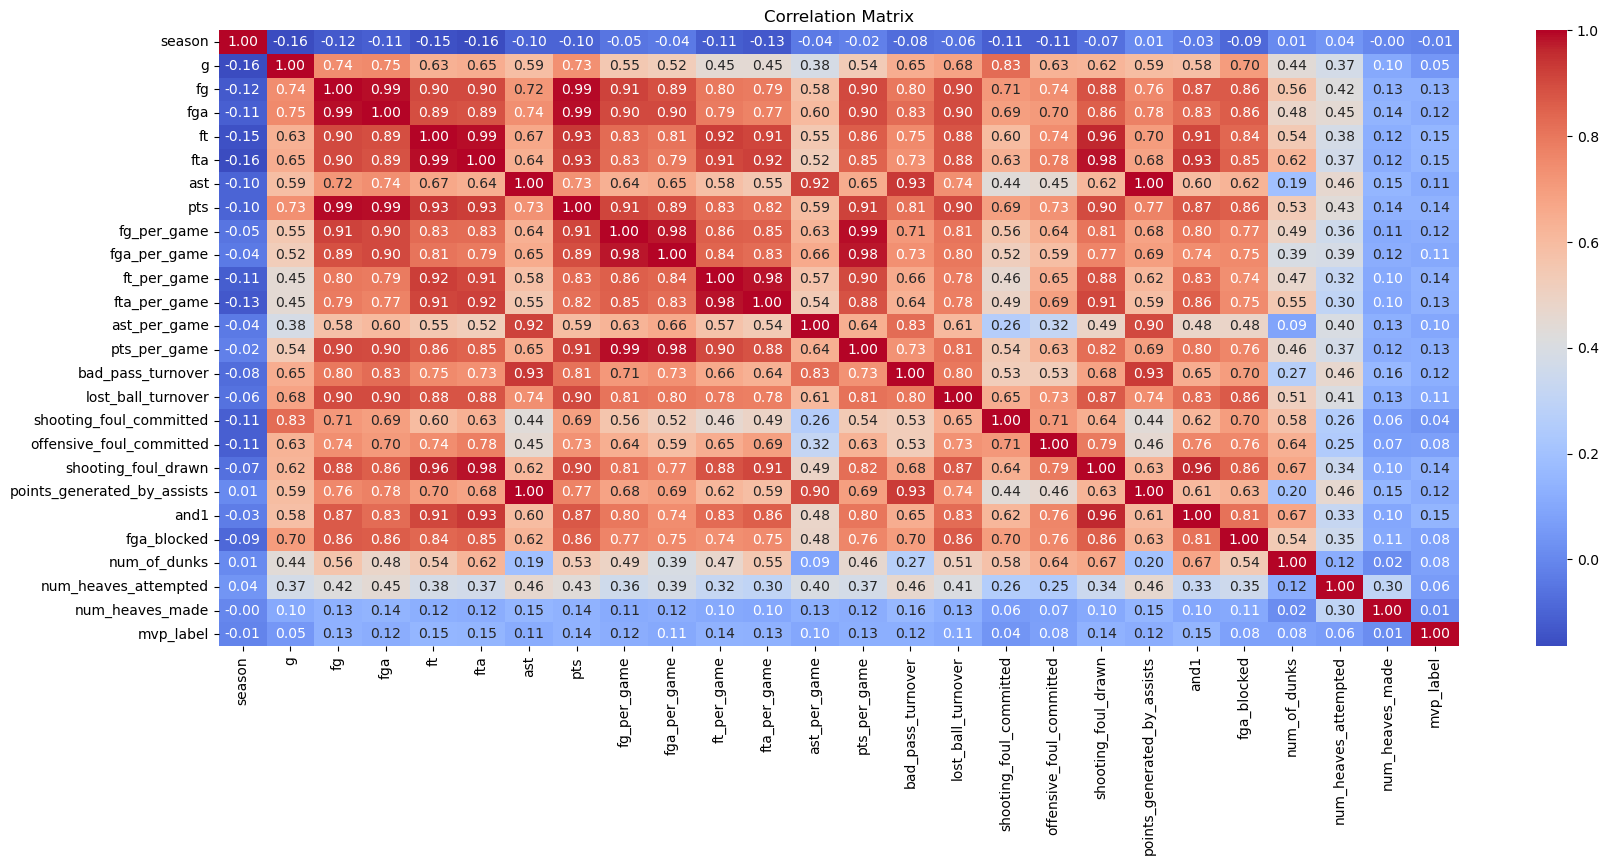

In [30]:
plt.figure(figsize=(20,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

## Variable Selection

In [ ]:
target_col = "mvp_label"
numeric_cols = [c for c, t in temp5.dtypes if t in ('int', 'double', 'float', 'bigint') and c != target_col]
string_cols = [c for c, t in temp5.dtypes if t == 'string']

print("Numeric:", numeric_cols)
print("String:", string_cols)



In [ ]:

pdf = temp5.select(numeric_cols + [target_col]).toPandas().dropna()
print("This is df for variable selection:", pdf.shape)

In [ ]:
# Remove highly correlated predictors
corr_matrix = pdf.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
pdf = pdf.drop(columns=to_drop)
print("Dropped highly correlated columns:", to_drop)

In [ ]:
# Remaining predictors
predictors = [c for c in pdf.columns if c != target_col]

In [ ]:
predictors

In [ ]:
def forward_selection(data, target, threshold_in=0.05):
    included = []
    while True:
        changed = False
        excluded = list(set(data.columns) - set(included) - {target})
        new_pval = pd.Series(index=excluded, dtype=float)
        for new_col in excluded:
            model = sm.Logit(data[target], sm.add_constant(data[included + [new_col]])).fit(disp=False)
            new_pval[new_col] = model.pvalues[new_col]
        best_pval = new_pval.min()
        if best_pval < threshold_in:
            best_feature = new_pval.idxmin()
            included.append(best_feature)
            changed = True
        if not changed:
            break
    return included

forward_features = forward_selection(pdf, target_col)
print("Forward Selection Chosen Variables:")
print(forward_features)

In [ ]:
# Backward Elimination
def backward_elimination(data, target, threshold_out=0.05):
    features = [c for c in data.columns if c != target]
    while True:
        model = sm.Logit(data[target], sm.add_constant(data[features])).fit(disp=False)
        pvals = model.pvalues.iloc[1:]  # exclude intercept
        worst_pval = pvals.max()
        if worst_pval > threshold_out:
            worst_feature = pvals.idxmax()
            features.remove(worst_feature)
        else:
            break
    return features

backward_features = backward_elimination(pdf, target_col)
print("Backward Elimination Chosen Variables:")
print(backward_features)

In [ ]:
# Compare
common_features = list(set(forward_features) & set(backward_features))
print("Common Features (selected by both):")
print(common_features)

In [ ]:

# --- Compute pairwise correlations ---
corr_pairs = []
for c1, c2 in itertools.combinations(numeric_cols, 2):
    corr = temp5.stat.corr(c1, c2)
    corr_pairs.append((c1, c2, corr))

# --- Identify highly correlated pairs ---
threshold = 0.9
high_corr = [(a,b,abs(c)) for a,b,c in corr_pairs if abs(c) > threshold]

print(f"Found {len(high_corr)} highly correlated pairs (>|{threshold}|)")
for a,b,c in high_corr[:10]:
    print(a,b,c)
assembler = VectorAssembler(inputCols=numeric_cols, outputCol="features")
df_vec = assembler.transform(temp5).select("features", target_col)

rf = RandomForestClassifier(labelCol=target_col, featuresCol="features", numTrees=100, maxDepth=5)
model = rf.fit(df_vec)

# Feature importances
importances = model.featureImportances.toArray()
importance_df = sorted(zip(numeric_cols, importances), key=lambda x: -x[1])

print("Top 15 features by importance:")
for f, imp in importance_df[:15]:
    print(f"{f}: {imp:.4f}")


to_drop = set()
for a, b, corr in high_corr:
    # keep the more important variable
    imp_a = dict(importance_df).get(a, 0)
    imp_b = dict(importance_df).get(b, 0)
    if imp_a >= imp_b:
        to_drop.add(b)
    else:
        to_drop.add(a)

final_features = [c for c in numeric_cols if c not in to_drop]
print("Selected features:", final_features)
print("Dropped features:", to_drop)
